# Proyecto de Análisis de Datos

Este proyecto tiene como objetivo analizar si existen diferencias significativas en el rendimiento académico de los estudiantes de grado décimo según la especialidad técnica cursada.

La base de datos contiene las calificaciones de 197 estudiantes en diferentes asignaturas académicas, así como la especialidad técnica a la que pertenece cada estudiante.

Se descargan las debidas librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, levene, kruskal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

#Se realiza la carga del archivo "Notas 10.xlsx".

In [ ]:
import pandas as pd
from google.colab import files
import io

print("Please upload your Excel file (e.g., Notas 10.xlsx).")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_excel(io.BytesIO(uploaded[fn]))
  print("File loaded successfully. Here are the first 5 rows:")
  print(df.head())

Please upload your Excel file (e.g., Notas 10.xlsx).


Saving Notas 10.xlsx to Notas 10.xlsx
User uploaded file "Notas 10.xlsx" with length 63617 bytes
File loaded successfully. Here are the first 5 rows:
   Column1                         Column2  LENG   TRIG  BIOLO  FISI  QUIM   \
0        1       AREVALO MESA DILAN ALEXIS    2.0   2.1    3.3   3.0    3.6   
1        2   BURGOS RUBIO ANGELA VALENTINA    2.0   2.3    2.3   2.1    2.0   
2        3     CAJAMARCA PRADO LAURA SOFIA    3.3   2.6    3.8   3.0    2.5   
3        4   CAMPOS BOLIVAR KEVIN SANTIAGO    3.0   2.3    2.1   1.4    2.0   
4        5  CASTAÑEDA ERASO NICOLE ALEJAND    4.2   2.7    3.9   3.0    2.8   

   FILO   CPOL   INGL   ...  EYV   INFO   Electricidad   Electronica  \
0    3.7    3.0    3.7  ...   3.7    3.3              1            0   
1    1.7    2.7    1.7  ...   3.8    2.2              1            0   
2    3.8    4.4    4.0  ...   4.0    3.4              1            0   
3    3.1    3.5    2.8  ...   3.6    2.4              1            0   
4    3.8    3.5

#Calcular el promedio académico general de cada estudiante.

In [ ]:
materias = [
    "LENG ",
    "TRIG",
    "BIOLO",
    "FISI",
    "QUIM ",
    "FILO ",
    "CPOL ",
    "INGL ",
    "EFIS ",
    "REL ",
    "EYV ",
    "INFO "
]

df["Promedio"] = df[materias].mean(axis=1)

df[["Column2", "Promedio"]].head()

,Column2,Promedio
0,AREVALO MESA DILAN ALEXIS,3.216667
1,BURGOS RUBIO ANGELA VALENTINA,2.375000
2,CAJAMARCA PRADO LAURA SOFIA,3.550000
3,CAMPOS BOLIVAR KEVIN SANTIAGO,2.683333
4,CASTAÑEDA ERASO NICOLE ALEJAND,3.525000


# Creación de la variable Técnica

Las especialidades técnicas se encuentran codificadas mediante variables binarias (One-Hot Encoding).

Se construye una variable categórica denominada Tecnica.

In [ ]:
tecnicas = [
    "Electricidad ",
    "Electronica",
    "Electromecanica",
    "Diseño corte y confeccion",
    "Soldadura ",
    "Ebanisteria",
    "Diseño arquitectonico",
    "Mecanica"
]

df["Tecnica"] = df[tecnicas].idxmax(axis=1)

df[["Column2", "Tecnica"]].head()

,Column2,Tecnica
0,AREVALO MESA DILAN ALEXIS,Electricidad
1,BURGOS RUBIO ANGELA VALENTINA,Electricidad
2,CAJAMARCA PRADO LAURA SOFIA,Electricidad
3,CAMPOS BOLIVAR KEVIN SANTIAGO,Electricidad
4,CASTAÑEDA ERASO NICOLE ALEJAND,Electricidad


# Estadística descriptiva por técnica

Se calculan medidas descriptivas para comparar el rendimiento académico entre especialidades.

In [ ]:
estadisticas = df.groupby("Tecnica")["Promedio"].agg(
    ["count", "mean", "std", "min", "max"]
)

estadisticas

,count,mean,std,min,max
Tecnica,,,,,
Diseño arquitectonico,42,3.625198,0.381031,2.525000,4.391667
Diseño corte y confeccion,26,3.648397,0.311484,2.575000,4.150000
Ebanisteria,19,3.346930,0.768121,0.633333,3.991667
Electricidad,32,3.461458,0.331607,2.375000,4.133333
Electromecanica,17,3.588725,0.324143,3.041667,4.175000
Electronica,33,3.490657,0.467256,2.516667,4.325000
Mecanica,13,3.428205,0.165431,3.166667,3.716667
Soldadura,15,3.585556,0.309192,3.058333,4.075000


# Visualización de datos

Se utiliza un diagrama de cajas para comparar la distribución de los promedios académicos entre técnicas.

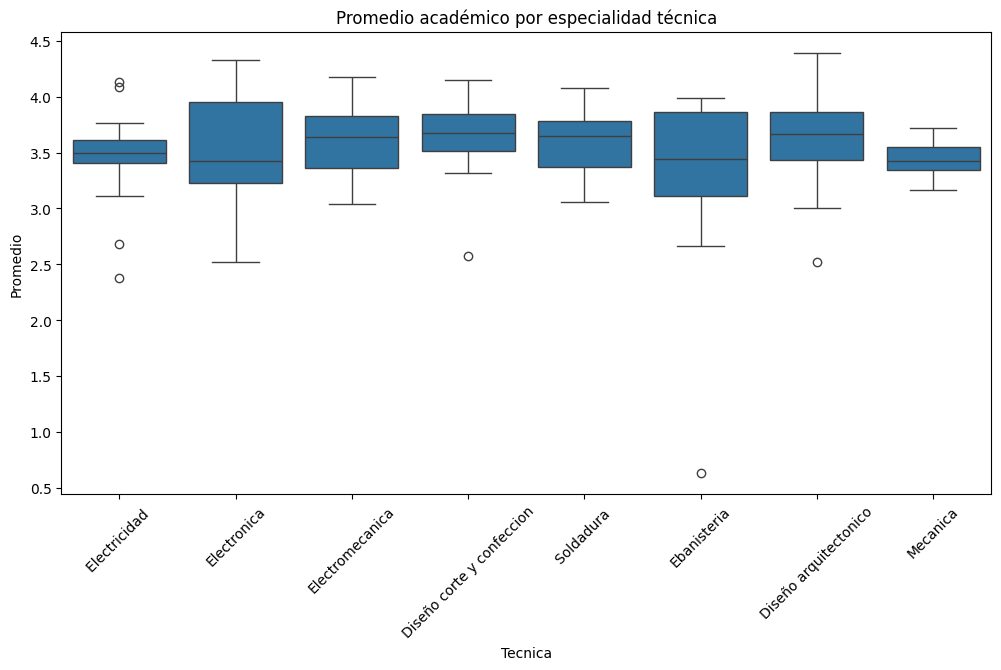

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Tecnica",
    y="Promedio"
)

plt.xticks(rotation=45)

plt.title("Promedio académico por especialidad técnica")

plt.show()

# Prueba de normalidad

Se aplica la prueba de Shapiro-Wilk sobre la variable Promedio.

In [ ]:
stat, p = shapiro(df["Promedio"])

print("Estadístico:", stat)
print("Valor p:", p)

Estadístico: 0.8936706808410941
Valor p: 1.2710801949356013e-10


# Homogeneidad de varianzas

Se aplica la prueba de Levene para verificar igualdad de varianzas entre grupos.

In [ ]:
grupos = [
    grupo["Promedio"].values
    for _, grupo in df.groupby("Tecnica")
]

stat, p = levene(*grupos)

print("Estadístico:", stat)
print("Valor p:", p)

Estadístico: 2.795972940218074
Valor p: 0.008615233430347797


#Prueba ANOVA
Para analizar si existen diferencias significativas en el Promedio General entre las distintas técnicas evaluadas, se utiliza un análisis de varianza (ANOVA de una vía). Este método es apropiado cuando se desea comparar las medias de más de dos grupos independientes, permitiendo determinar si al menos uno de ellos presenta diferencias estadísticamente significativas respecto a los demás.

El ANOVA parte de las siguientes hipótesis:

H0 (hipótesis nula): Todas las técnicas presentan la misma media en el Promedio General.
H1 (hipótesis alternativa): Al menos una técnica presenta una media diferente.

Antes de su aplicación, se asume que los datos cumplen con condiciones de normalidad y homogeneidad de varianzas, verificadas previamente mediante las pruebas de Shapiro-Wilk y Levene.

In [ ]:
from scipy.stats import f_oneway

In [ ]:
df.columns = df.columns.str.strip()

grupos = df.groupby('Tecnica')['Promedio'].apply(list)

grupos

,Promedio
Tecnica,
Diseño arquitectonico,"[3.691666666666667, 4.358333333333333, 3.74166..."
Diseño corte y confeccion,"[3.4583333333333326, 3.508333333333334, 2.575,..."
Ebanisteria,"[0.6333333333333333, 3.033333333333333, 2.6666..."
Electricidad,"[3.216666666666667, 2.3749999999999996, 3.5500..."
Electromecanica,"[3.691666666666667, 3.5083333333333333, 3.8833..."
Electronica,"[2.516666666666667, 3.3249999999999997, 4.1999..."
Mecanica,"[3.1666666666666665, 3.716666666666667, 3.3750..."
Soldadura,"[3.866666666666666, 3.525000000000001, 3.64999..."


In [ ]:
stat, p = f_oneway(*grupos)

print("Estadístico F:", stat)
print("Valor p:", p)

if p < 0.05:
    print("👉 Se rechaza H0: hay diferencias significativas entre técnicas")
else:
    print("👉 No se rechaza H0: no hay diferencias significativas")

Estadístico F: 1.5016772453027927
Valor p: 0.1688669645721388
👉 No se rechaza H0: no hay diferencias significativas


# Prueba de Kruskal-Wallis

Debido a que los supuestos del ANOVA no se cumplen completamente y no se rechaza H0, se utiliza una prueba no paramétrica para comparar las especialidades técnicas.

In [ ]:
H, p = kruskal(*grupos)

print("Estadístico H:", H)
print("Valor p:", p)

Estadístico H: 11.0187530826832
Valor p: 0.13780310967920215


Dado que el valor p es mayor a 0.05, no se rechaza la hipótesis nula. Esto indica que no existen diferencias estadísticamente significativas entre las técnicas evaluadas en relación con el Promedio General.

En otras palabras, los resultados sugieren que el comportamiento de las técnicas es similar desde el punto de vista estadístico.